# Fund X-ray (N-PORT)

Registered funds disclose complete monthly portfolios on Form N-PORT,
with every holding categorized: asset class, issuer type, country, and
fair-value level. That last one is where the interesting questions live
(level 3 means the fund priced it with unobservable inputs).

Needs `pandas` and `matplotlib`, and a free API key in
`THREESPREAD_API_KEY` ([signup](https://3spread.com/auth/signup)).

In [1]:
import pandas as pd

from py3spread import Client

client = Client()

import itertools

registrant = client.fund_portfolios.entities(search="pimco", limit=1)["data"][0]
filing = client.fund_portfolios.list(registrant_cik=registrant["cik"], limit=1)["data"][0]
holdings = pd.DataFrame(itertools.islice(client.fund_portfolios.iter_holdings(
    filing_id=filing["filing_id"], sort="val_usd", order="desc", limit=500), 3000))
holdings["val_usd"] = pd.to_numeric(holdings["val_usd"])
names = holdings["series_name"].replace("N/A", pd.NA).dropna()
fund = names.iloc[0] if len(names) else registrant["company_name"]
print(f"{fund}: {len(holdings)} positions, period {holdings['period_of_report'].iloc[0]}")

PIMCO Access Income Fund: 499 positions, period 2025-12-31


## Composition

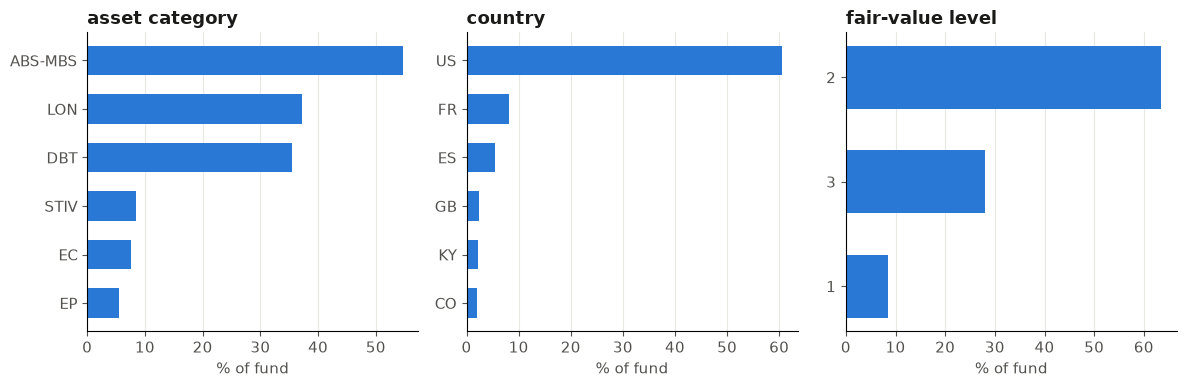

In [2]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e8e7e2",
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "font.size": 11,
    "text.color": "#1a1a19",
    "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
})
BLUE = "#2a78d6"
INK = "#52514e"


fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col, title in [
    (axes[0], "asset_cat", "asset category"),
    (axes[1], "inv_country", "country"),
    (axes[2], "fair_val_level", "fair-value level"),
]:
    mix = holdings.groupby(col)["val_usd"].sum().sort_values() / holdings["val_usd"].sum() * 100
    mix = mix.tail(6)
    ax.barh([str(i) for i in mix.index], mix.values, color=BLUE, height=0.6)
    ax.set_title(title, loc="left", fontweight="bold")
    ax.set_xlabel("% of fund")
    ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

## The level-3 question

Screening every fund for hard-to-value concentration is the same query
with `fair_val_level=3` pushed to the server:

In [3]:
lvl3 = client.fund_portfolios.holdings(fair_val_level=3, registrant_cik=registrant["cik"], limit=10)["data"]
print(f"level-3 positions at this registrant: {len(lvl3)}")
if lvl3:
    pd.DataFrame(lvl3)[["series_name", "name", "asset_cat", "val_usd"]]

level-3 positions at this registrant: 10


An index fund holding zero level-3 assets is the boring, correct
answer. Point the same filter at credit or private-heavy funds and it
gets interesting fast.